In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display

import gc
import itertools

In [2]:
%%bash
ls "../../mnt/SingleTrackTrees/Simulation/alice_sim_2024_LHC24h1_1_536237_AOD"

001_010
011_020
021_030
031_040
041_050
051_060
061_070
071_080
081_090
091_100


In [3]:
base_path = "../../mnt/SingleTrackTrees/Simulation/alice_sim_2024_LHC24h1_1_536237_AOD"
#which_chunk = ["001_010", "011_020", "021_030", "031_040", "041_050", "051_060", "061_070", "071_080", "081_090", "091_100" ]
which_chunk = ["001_010", "011_020", "021_030", "031_040"]
which_file = "AO2Dtree.root"

In [4]:
def to_global_coord( row ):
    xy_in = np.array([row["fX"],row["fY"]])
    # angle = -row["fAlpha"]
    # rot = np.array([[np.cos(angle),np.sin(angle)], [-np.sin(angle), np.cos(angle)]]) # inverse matrix of the one from to_track_coord (-alfa)
    # Rewriting the above matrix using cosine/sin even/odd function properties: less multiplications
    angle = row["fAlpha"]
    rot = np.array([[np.cos(angle),-np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    xy_out = rot.dot(xy_in)
    return( xy_out )

def secondary_vertex ( row1, row2 ):
    XY1, XY2 = [to_global_coord(row1), to_global_coord(row2)]
    x1 = XY1[0]
    y1 = XY1[1]
    x2 = XY2[0]
    y2 = XY2[1]
    
    px1 = row1["px"]
    px2 = row2["px"]
    py1 = row1["py"]
    py2 = row2["py"]
    pz1 = row1["pz"]
    pz2 = row2["pz"]
    
    m1 = py1/px1
    m2 = py2/px2
    q1 = y1 - m1*x1
    q2 = y2 - m2*x2
    x_SV = ( q2 - q1 )/( m1 - m2)
    y_SV = y1 + m1*(x_SV - x1)
   
    z1_track = pz1/px1 * (x_SV - x1) + row1["fZ"]
    z2_track = pz2/px2 * (x_SV - x2) + row2["fZ"]
    z_SV = (z1_track + z2_track)/2
    return ([x_SV, y_SV, z_SV])

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

$$
\begin{align}
D^0 \rightarrow K^- \quad \pi^+ \\
421 \rightarrow -321 \quad211
\end{align}
$$


$$
\begin{align}
\overline{D^0} \rightarrow& \quad K^+ \qquad \pi^- \\
-421 \rightarrow& +321 \quad-211
\end{align}
$$

In [5]:
# NSigmaTPC:
sigma_limit = 3
cut1 = (
    "( (fNsigmaTPCpi > -3) & (fNsigmaTPCpi < 3) & (fCharge == 1) ) | "
    "( (fNsigmaTPCka > -3) & (fNsigmaTPCka < 3) & (fCharge == -1) ) | "
    "( (fPt > 0) & (fPt < 1) & (fNsigmaTPCka > -15) & (fNsigmaTPCka < 0) & (fCharge == 1) )"
)

# NsigmaTOF:
sigma_limit = 3
cut2 = (
    "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
    "( (fNsigmaTOFka > -3) & (fNsigmaTOFka < 3) & (fCharge == -1) ) | "
    "( (fNsigmaTOFka > 998.5) | (fNsigmaTOFka < -998.5) | (fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "
    "( (fPt > 0) & (fPt < 3) & (fNsigmaTOFka > -50) & (fNsigmaTOFka < 0) & (fCharge == 1) )"
)

# DCA_XY:
cut3 = "( (fDcaXY > 0.0002) | (fDcaXY < -0.0002) )"


# FINAL CUT EXPRESSION:
cut_expression = f"({cut1}) & ({cut2}) & ({cut3})"

In [6]:
collision_offset = 0          # variable to correct the index of the collision (because it starts from 0 at each new TTree)
filtered_dfs = []

for chunk in which_chunk:
    path = base_path + "/".join(["/", chunk, which_file])
    file = uproot.open(path)

    names_track_extr = file.keys(filter_name=r"*O2filtertrackextr")
    names_track      = file.keys(filter_name=r"*O2filtertrack")
    names_coll       = file.keys(filter_name=r"*O2collision_001")
    
    names_mc_gen     = file.keys(filter_name=r"*O2genparticles")
    names_mc_track   = file.keys(filter_name=r"*O2filtertrackmc")
    names_mc_coll    = file.keys(filter_name=r"*O2mccollision")

    list_of_df = []               # add the dataframes in a list (we will concat them later)

    for i in range (len(names_coll)):
        # Read collision tree
        df_coll = file[ names_coll[i] ].arrays(["fPosX", "fPosY", "fPosZ"], library="pd")   # I take the fPosZ column as a DataFrame
    
        # # Read track and trackextr using boolean mask for track and trackextr:
        df_trackextr = file[ names_track_extr[i] ].arrays(["fPt", "fEta", "fCharge", "fDcaXY",
             "fNsigmaTPCpi", "fNsigmaTPCka", "fNsigmaTPCpr", "fNsigmaTOFpi", "fNsigmaTOFka"], library="pd" )
        df_track = file[ names_track[i] ].arrays(["fIndexCollisions", "fAlpha", "fX", "fY", "fZ"], library="pd")
    
        # take the corresponding data of MC
        df_track_mc = file[names_mc_track[i]].arrays(["fPdgCode","fMainMotherOrigIndex","fMainHfMotherPdgCode","fMainMotherNfinalStateDaught",
                                                      "fMainBeautyAncestorPdgCode"],library="pd")
        df_track = pd.merge(left=df_track, 
                             right=df_track_mc, 
                             how='inner', left_index=True, right_index=True)
    
        # merge all rows
        df_trackextr = pd.merge(left=df_trackextr, right=df_track, how='inner', left_index=True, right_index=True)
    
        # keep all particles that DO NOT come from D0 AND are either K- or pi+ AND fMainBeautyAncestor = 0 or the equivalent for anti-D0
        df_trackextr = df_trackextr[( np.invert(df_trackextr["fMainHfMotherPdgCode"].isin([421,-421])) ) &
            (np.invert(df_trackextr["fPdgCode"].isin([-321,211, +321, -211])) ) ]
    
    
        # mask = df_trackextr.eval(cut_expression)        # create boolean mask
        # # Apply the SAME filter to df_trackextr and df_track to keep them aligned (and keep only useful columns):
        # df_trackextr = df_trackextr.loc[mask, ["fIndexCollisions","fAlpha", "fX", "fY", "fZ","fPt", "fEta",
        #                                        "fCharge", "fDcaXY","fPdgCode"] ].reset_index(drop=True)

        # NEW: We keep the variables over which we did the cut to see how they behave for the signal
        df_trackextr = df_trackextr[["fIndexCollisions","fAlpha", "fX", "fY", "fZ","fPt", "fEta", "fCharge", "fDcaXY","fPdgCode",
                                    "fNsigmaTPCpi", "fNsigmaTPCka","fNsigmaTOFpi", "fNsigmaTOFka"]]
    
        # we cut rows where the fIndexCollision is negative (for some reason)
        valid = df_trackextr["fIndexCollisions"] >= 0
        df_trackextr = df_trackextr[valid].reset_index(drop=True)  

        # additional check: for BKG we still want only particles with charge +-1
        df_trackextr = df_trackextr[ df_trackextr["fCharge"].isin([-1,1]) ]
        
        # Now we for correct fPosZ (and add that column)
        df_trackextr["fPosZ"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosZ"].values
      
        df_trackextr["fPosX"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosX"].values
    
        df_trackextr["fPosY"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosY"].values
    
        df_trackextr = df_trackextr[(df_trackextr["fPosZ"] < 10) & (df_trackextr["fPosZ"] > -10)].reset_index(drop=True)
        df_trackextr["fIndexCollisions"] += collision_offset   # Fix local fIndexCollisions → global index
    
        # save results:
        # ALTERNATIVE 1: for the first cycle, let's copy the first dataframe, then we concatenate the next ones
        # if  i==0: df = df_trackextr
        # else: df = pd.concat([df, df_trackextr], ignore_index=True)
        # # ALTERNATIVE 2:
        list_of_df.append( df_trackextr )                  # add the dataframe in a list (we will concat them later)
        
        # Update offset for next loop
        collision_offset += len(df_coll)

    # Merge everything in the total dataframe
    df = pd.concat(list_of_df, ignore_index=True)
    
    N = len(df)
    
    # moment columns:
    df["px"] = df["fPt"] * np.cos(df["fAlpha"])
    df["py"] = df["fPt"] * np.sin(df["fAlpha"])
    df["pz"] = df["fPt"] * np.sinh(df["fEta"])
    
    # energy column (differentiating pions and kaons):
    mass = np.where(df["fCharge"] == 1, m_pi, m_K)
    df["Ene"] = np.sqrt((df["fPt"] * np.cosh(df["fEta"]))**2 + mass**2)
    
    # Debug
    print(f"The dataframe before pair computation of chunk {chunk} has", len(df), "rows and ", len(df.columns), "columns.")
    memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"It occupies {memory:.2f} MB")

    # let's initialize some lists, then we will create a dataframe
    collision_indices = []
    track1_indices = []
    track2_indices = []
    dcaXY_products = []
    inv_masses = []
    inv_masses_approx = []
    pt_totals = []
    pz_totals = []
    SV_X = []
    SV_Y = []
    SV_Z = []
    decay_lengths = []
    cos_pointings = []

    # filter variables behaviour
    KA_TPCka = []
    KA_TOFka = []
    PI_TPCpi = []
    PI_TOFpi = []

    # also cross-check over the other particles's variables (e.g. the TOFpi for a ka particle)
    KA_TPCpi = []
    KA_TOFpi = []
    PI_TPCka = []
    PI_TOFka = []

    # also for the fDCAXY of the two daughters
    KA_fDcaXY = []
    PI_fDcaXY = []

    # and their transverse momentum
    KA_pt = []
    PI_pt = []
    
    counting=0 # debug variable
    
    # let's divide the dataframe for positive and negative charged
    df_pos = df[ df['fCharge']>0 ]
    df_neg = df[ df['fCharge']<0 ]
    
    # Iterate over each collision group
    for collision_idx in (df_neg['fIndexCollisions'].unique()):
        group_pos = df_pos[ df_pos['fIndexCollisions'] == collision_idx ]
        group_neg = df_neg[ df_neg['fIndexCollisions'] == collision_idx ]
    
        # Only collisions with at least a pair
        if len(group_pos) < 1:   continue
    
        # Reset index of the group to 0..N-1 and move original index in new column 'orig_index'
        group_pos = group_pos.reset_index().rename(columns={'index': 'orig_index'})
        group_neg = group_neg.reset_index().rename(columns={'index': 'orig_index'})
    
        # let's crate indexes for all possible pairs:
        combinat = itertools.product( range(len(group_neg)), range(len(group_pos)) )
    
        # Iterate over all unique pairs of tracks
        for combo in combinat:
            row_neg = group_neg.iloc[combo[0]]
            row_pos = group_pos.iloc[combo[1]]
    
            product_dcaXY = row_neg['fDcaXY'] * row_pos['fDcaXY']
            
            # INVARIANT MASS calculation
            pt1, pt2 = row_neg['fPt'], row_pos['fPt']
            # eta1, eta2 = row_neg['fEta'], row_pos['fEta']
            # phi1, phi2 = row_neg['fAlpha'], row_pos['fAlpha']
            # delta_eta = eta1 - eta2
            # delta_phi = phi1 - phi2
    
            # approximation formula
            # inv_mass_approx = np.sqrt(2 * pt1 * pt2 * (np.cosh(delta_eta) - np.cos(delta_phi)))
    
            # exact formula:
            E1 = row_neg['Ene']
            E2 = row_pos['Ene']
            px1 = row_neg["px"]
            py1 = row_neg["py"]
            pz1 = row_neg["pz"]
            px2 = row_pos["px"]
            py2 = row_pos["py"]
            pz2 = row_pos["pz"]
            inv_mass = np.sqrt( (E1+E2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2 )
    
    
            # total transverse momentum of the D0 candidate (used later for sliced plots)
            pt_total = np.sqrt((px1 + px2)**2 + (py1 + py2)**2)
    
            # secondary vertex
            SV_coords = np.array( secondary_vertex(row_neg, row_pos) )
            # SV_X.append(SV_coords[0])
            # SV_Y.append(SV_coords[1])
            # SV_Z.append(SV_coords[2])
    
            # decay length: distance between PV and SV
            PV_coords = np.array( [row_pos["fPosX"], row_pos["fPosY"], row_pos["fPosZ"]] )
            decay_lengths.append( np.linalg.norm(SV_coords - PV_coords ) )
    
            # cosine of pointing angle: the latter is the angle between the direction of the mother particle and the line connecting PV and SV
            mother_direction = [px1+px2, py1+py2, pz1+pz2]
            flight_line = SV_coords - PV_coords
            cos_pointings.append ( np.dot(mother_direction, flight_line)/(np.linalg.norm(mother_direction)*np.linalg.norm(flight_line)) )
            
            # let's add the found pairs to the lists
            collision_indices.append(int(row_neg['fIndexCollisions']))
            # track1_indices.append(int(row_neg['orig_index']))
            # track2_indices.append(int(row_pos['orig_index']))
            dcaXY_products.append(product_dcaXY)
            inv_masses.append(inv_mass)
            # inv_masses_approx.append(inv_mass_approx)
            pt_totals.append(pt_total)
            pz_totals.append(pz1+pz2)
            # variable check: for D0, kaon is minus---> Ka<-->row neg; pi<-->row pos
            
            KA_pt.append(row_neg['fPt'])
            KA_TPCka.append(row_neg["fNsigmaTPCka"])
            KA_TOFka.append(row_neg["fNsigmaTOFka"])
            KA_fDcaXY.append(row_neg["fDcaXY"])

            PI_pt.append(row_pos['fPt'])
            PI_TPCpi.append(row_pos["fNsigmaTPCpi"])
            PI_TOFpi.append(row_pos["fNsigmaTOFpi"])
            PI_fDcaXY.append(row_pos["fDcaXY"])
        
            # also cross-check over the other particles's variables (e.g. the TOFpi for a ka particle)
            KA_TPCpi.append(row_neg["fNsigmaTPCpi"])
            KA_TOFpi.append(row_neg["fNsigmaTOFpi"])
            PI_TPCka.append(row_pos["fNsigmaTPCka"])
            PI_TOFka.append(row_pos["fNsigmaTOFka"])
    
        # # let's free the memory RAM of unused dataframes:
        # # PROBLEM: THIS IS VERY SLOW!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
        # del group
        # gc.collect()
    
        # debug:
        counting += 1
        if counting % 50000 ==0: print(counting, end=' ')


    # create a dataframe with the result:
    df_pairs = pd.DataFrame({
        'collision_index': collision_indices,
        'dcaXY_product': dcaXY_products,
        'inv_mass': inv_masses,
        'pt': pt_totals,
        'pz': pz_totals,
        'decay_length': decay_lengths,
        'cos_pointing': cos_pointings,
        'KA_pt': KA_pt,
        'KA_TPCka': KA_TPCka,
        'KA_TOFka': KA_TOFka,
        'KA_fDcaXY': KA_fDcaXY,
        'PI_pt': PI_pt,
        'PI_TPCpi': PI_TPCpi,
        'PI_TOFpi': PI_TOFpi,
        'PI_fDcaXY': PI_fDcaXY,
        'KA_TPCpi': KA_TPCpi,
        'KA_TOFpi': KA_TOFpi,
        'PI_TPCka': PI_TPCka,
        'PI_TOFka': PI_TOFka
    })
    # Debug
    print(f"The final dataframe after filters and pair computation of chunk {chunk} has", len(df_pairs), "rows and ",
          len(df_pairs.columns), "columns.")
    memory = df_pairs.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"It occupies {memory:.2f} MB")
    display( pd.concat([df_pairs.head(3),df_pairs.tail(3)]) )

    filtered_dfs.append(df_pairs)

final_results = pd.concat(filtered_dfs,ignore_index=True)

The dataframe before pair computation of chunk 001_010 has 156835 rows and  21 columns.
It occupies 13.16 MB
The final dataframe after filters and pair computation of chunk 001_010 has 61439 rows and  19 columns.
It occupies 8.91 MB


,collision_index,dcaXY_product,inv_mass,pt,pz,decay_length,cos_pointing,KA_pt,KA_TPCka,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,2,0.000005,1.225685,3.566073,0.331722,0.009189,-0.931800,2.820192,-0.858816,11.830413,-0.001041,0.822375,12.974496,86.617554,-0.005145,-2.222589,14.827864,10.183949,42.177925
1,2,-0.000061,1.101948,1.320438,0.177381,0.026686,-0.993488,0.573957,15.066970,49.151630,0.011905,0.822375,12.974496,86.617554,-0.005145,25.062372,139.430527,10.183949,42.177925
2,2,-0.000723,0.998911,1.284897,0.111261,0.680888,-0.986836,0.469854,-5.300899,-36.159904,0.140618,0.822375,12.974496,86.617554,-0.005145,0.255701,0.303914,10.183949,42.177925
61436,219043,0.000048,0.763780,1.490259,-0.239167,0.075420,-0.971962,0.868130,5.211627,44.044796,0.001391,0.660672,23.643589,-999.000000,0.034294,7.577961,86.222557,14.683125,-999.000000
61437,219043,-0.000006,0.853135,1.407716,0.132303,0.026949,-0.998796,0.868130,5.211627,44.044796,0.001391,0.547751,39.399982,-999.000000,-0.004523,7.577961,86.222557,21.655144,-999.000000
61438,219048,0.000001,1.476850,0.822058,0.577447,0.002124,-0.135044,0.850278,5.659565,-999.000000,-0.001239,0.684819,18.481035,-999.000000,-0.000987,7.707085,-999.000000,12.720963,-999.000000


The dataframe before pair computation of chunk 011_020 has 334744 rows and  21 columns.
It occupies 28.09 MB
50000 The final dataframe after filters and pair computation of chunk 011_020 has 132334 rows and  19 columns.
It occupies 19.18 MB


,collision_index,dcaXY_product,inv_mass,pt,pz,decay_length,cos_pointing,KA_pt,KA_TPCka,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,219086,0.000022,1.078569,1.536841,-0.042281,0.011476,-0.773486,0.846765,6.738606,41.823837,-0.008850,0.795017,16.099089,95.229752,-0.002478,8.123312,83.536018,13.019639,46.186314
1,219086,0.000047,1.245303,0.958636,0.179829,0.019602,0.694300,0.532833,27.193985,-999.000000,-0.019125,0.795017,16.099089,95.229752,-0.002478,66.941269,-999.000000,13.019639,46.186314
2,219115,-0.000006,1.306142,0.220732,0.014815,0.007961,0.976411,0.639200,16.191589,-999.000000,0.001880,0.443981,8.668344,-999.000000,-0.003294,26.840487,-999.000000,-2.042998,-999.000000
132331,682328,-0.000177,0.840037,1.037674,-0.603199,0.983058,-0.634092,0.801218,8.499734,45.651035,0.001251,0.367937,160.202087,-999.000000,-0.141678,10.506814,93.804756,39.633999,-999.000000
132332,682329,-0.000004,1.049185,1.759345,0.478275,0.020485,0.971000,1.218872,1.488603,-999.000000,-0.000304,0.624278,29.613342,128.873108,0.011909,0.437809,-999.000000,16.874453,45.880348
132333,682330,-0.000004,2.758565,2.380649,0.864904,0.003526,0.922511,1.568060,1.394349,18.373999,-0.002983,1.575421,-1.107850,-999.000000,0.001400,-0.556807,26.865911,0.116375,-999.000000


The dataframe before pair computation of chunk 021_030 has 220565 rows and  21 columns.
It occupies 18.51 MB
The final dataframe after filters and pair computation of chunk 021_030 has 87033 rows and  19 columns.
It occupies 12.62 MB


,collision_index,dcaXY_product,inv_mass,pt,pz,decay_length,cos_pointing,KA_pt,KA_TPCka,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,682369,0.000005,1.040594,1.960320,-0.399501,0.022654,-0.994277,0.623571,14.303220,47.042290,-0.005829,1.347924,2.106754,43.462387,-0.000797,19.931744,117.552124,3.299690,28.533369
1,682384,-0.000002,1.244524,3.200377,0.196875,0.008329,-0.962833,1.187620,6.899156,29.625965,0.000485,2.098529,-1.021826,-999.000000,-0.003380,6.102708,49.215069,0.586316,-999.000000
2,682384,-0.000029,2.401357,0.854355,0.297658,0.088908,-0.329770,1.187620,6.899156,29.625965,0.000485,1.226155,-1.030654,-999.000000,-0.058942,6.102708,49.215069,-0.602567,-999.000000
87030,986427,0.000019,1.946489,2.797268,-1.441561,0.005833,-0.595736,0.804049,11.639787,-999.000000,0.005193,2.427967,-1.581417,-999.000000,0.003677,16.754625,-999.000000,0.351459,-999.000000
87031,986428,-0.013032,0.776439,0.683682,-0.637348,2.884833,0.602936,0.424935,-5.971067,-999.000000,-0.060764,0.349046,70.462257,-999.000000,0.214464,1.238139,-999.000000,25.843218,-999.000000
87032,986428,-0.009786,0.933368,0.872969,-0.078464,2.315393,-0.158172,0.424935,-5.971067,-999.000000,-0.060764,0.465016,57.060680,-999.000000,0.161042,1.238139,-999.000000,25.415716,-999.000000


The dataframe before pair computation of chunk 031_040 has 151203 rows and  21 columns.
It occupies 12.69 MB
The final dataframe after filters and pair computation of chunk 031_040 has 55663 rows and  19 columns.
It occupies 8.07 MB


,collision_index,dcaXY_product,inv_mass,pt,pz,decay_length,cos_pointing,KA_pt,KA_TPCka,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,986468,0.079245,0.942942,1.438188,-0.844250,2.250991,-0.365096,0.314184,-8.560867,-999.000000,-0.302006,1.125732,4.019982,4480.879883,-0.262394,1.401696,-999.000000,4.939300,397.407013
1,986468,-0.042637,1.998401,1.613432,0.341490,1.461655,0.009951,0.314184,-8.560867,-999.000000,-0.302006,1.840541,-0.438081,-999.000000,0.141178,1.401696,-999.000000,1.263506,-999.000000
2,986484,-0.002534,1.064213,1.723049,-0.573387,2.988794,-0.378276,0.432777,-6.959073,134.848190,-0.101888,1.361011,-1.757613,5293.775879,0.024873,0.784858,969.017151,-0.946342,460.848267
55660,1207119,-0.001035,1.260939,0.116041,-0.030869,0.363947,-0.064256,0.419912,29.198280,-999.000000,-0.064558,0.432287,0.523030,-3.038967,0.016038,68.999176,-999.000000,-5.984538,-41.884068
55661,1207122,0.002389,1.921633,0.150819,1.207718,1.125456,-0.091392,0.939979,4.700836,32.888451,0.137268,0.853103,8.172967,70.804855,0.017404,4.531274,61.333031,7.835701,35.472282
55662,1207128,0.003561,3.009354,1.714252,0.057118,0.634481,0.435857,0.864286,12.078572,-263.059235,-0.022868,2.427835,-0.502389,-10741.240234,-0.155705,14.940852,-2701.274658,1.435820,-915.493591


In [7]:
print(f"The final dataframe over all chunks has {len(final_results)} rows and {len(final_results.columns)} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:.2f} MB")
final_results

The final dataframe over all chunks has 336469 rows and 19 columns.
It occupies 48.77 MB


,collision_index,dcaXY_product,inv_mass,pt,pz,decay_length,cos_pointing,KA_pt,KA_TPCka,KA_TOFka,KA_fDcaXY,PI_pt,PI_TPCpi,PI_TOFpi,PI_fDcaXY,KA_TPCpi,KA_TOFpi,PI_TPCka,PI_TOFka
0,2,0.000005,1.225685,3.566073,0.331722,0.009189,-0.931800,2.820192,-0.858816,11.830413,-0.001041,0.822375,12.974496,86.617554,-0.005145,-2.222589,14.827864,10.183949,42.177925
1,2,-0.000061,1.101948,1.320438,0.177381,0.026686,-0.993488,0.573957,15.066970,49.151630,0.011905,0.822375,12.974496,86.617554,-0.005145,25.062372,139.430527,10.183949,42.177925
2,2,-0.000723,0.998911,1.284897,0.111261,0.680888,-0.986836,0.469854,-5.300899,-36.159904,0.140618,0.822375,12.974496,86.617554,-0.005145,0.255701,0.303914,10.183949,42.177925
3,4,-0.003587,0.925079,0.403113,0.210919,0.239874,-0.697384,0.451235,33.944710,-999.000000,0.016546,0.308587,0.716939,-999.000000,-0.216763,109.017822,-999.000000,-7.396849,-999.000000
4,7,-0.000055,1.039468,1.318667,-0.099854,0.075110,0.746066,0.409640,-7.288838,-45.391518,0.040980,0.991924,6.369393,68.003983,-0.001341,0.692608,-0.448025,5.950290,38.067963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336464,1207114,-0.020646,1.207236,1.573716,-0.761171,2.967991,0.329141,1.312982,1.791645,535.907898,0.099269,0.391178,0.916609,-999.000000,-0.207977,0.230521,5782.134766,-7.904965,-999.000000
336465,1207114,-0.027111,1.862016,1.191065,-0.651190,3.437193,0.547931,1.312982,1.791645,535.907898,0.099269,0.545912,33.965286,-999.000000,-0.273105,0.230521,5782.134766,19.462278,-999.000000
336466,1207119,-0.001035,1.260939,0.116041,-0.030869,0.363947,-0.064256,0.419912,29.198280,-999.000000,-0.064558,0.432287,0.523030,-3.038967,0.016038,68.999176,-999.000000,-5.984538,-41.884068
336467,1207122,0.002389,1.921633,0.150819,1.207718,1.125456,-0.091392,0.939979,4.700836,32.888451,0.137268,0.853103,8.172967,70.804855,0.017404,4.531274,61.333031,7.835701,35.472282


In [8]:
final_results.to_pickle("BKG_001_040.pkl")

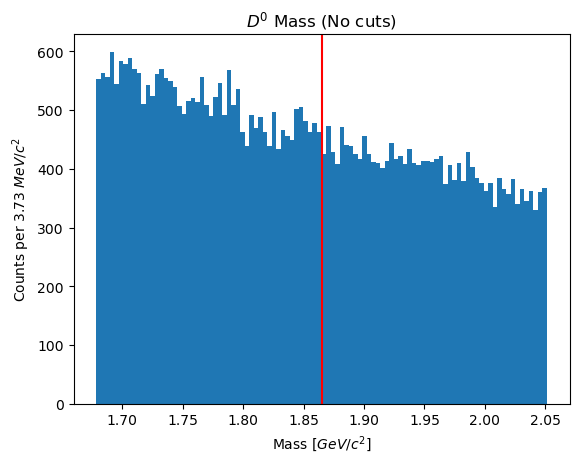

In [9]:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
plt.hist(final_results["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
plt.axvline(x=m_d0, color="red")
plt.xlabel("Mass [$GeV/c^2$]")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
plt.title("$D^0$ Mass (No cuts)")
#plt.savefig("D0_Mass_MC.png")
plt.show()

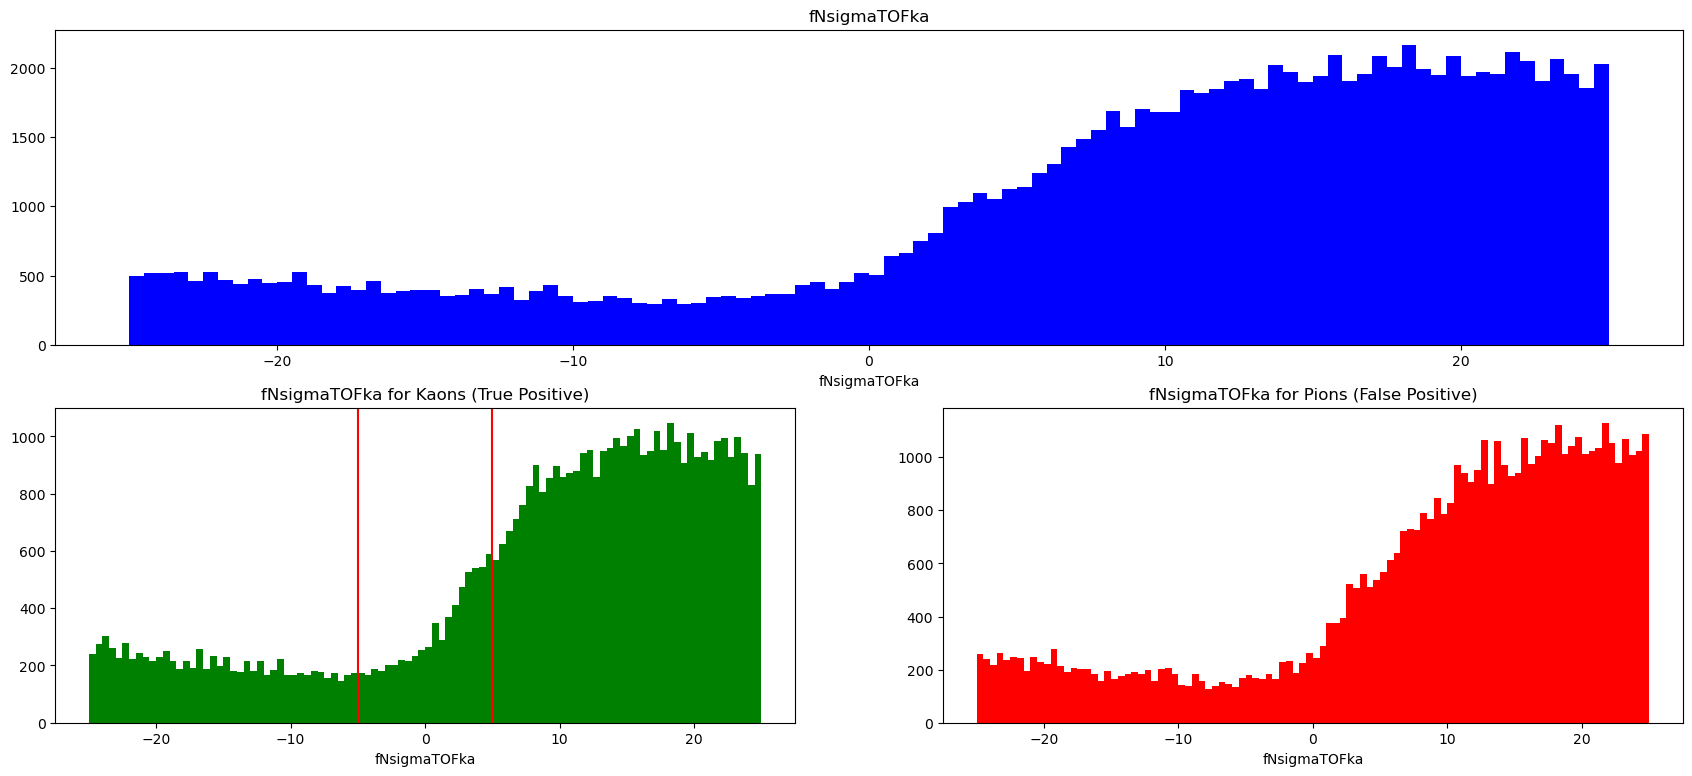

In [10]:
mosaic = [
    ["top", "top"],
    ["left", "right"]
]

fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TOF, MAX_TOF = -25, 25
axes["top"].hist(np.concat([final_results["KA_TOFka"],final_results["PI_TOFka"]]), bins=N_BINS, color="blue", range=(MIN_TOF, MAX_TOF))
axes["top"].set_title("fNsigmaTOFka")
axes["top"].set_xlabel("fNsigmaTOFka")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["KA_TOFka"], bins=N_BINS, color="green", range=(MIN_TOF, MAX_TOF))
axes["left"].set_title("fNsigmaTOFka for Kaons (True Positive)")
axes["left"].set_xlabel("fNsigmaTOFka")
axes["left"].set_label("Counts")
axes["left"].axvline(x=-5, color="red")
axes["left"].axvline(x=+5, color="red")

axes["right"].hist(final_results["PI_TOFka"], bins=N_BINS, color="red", range=(MIN_TOF, MAX_TOF))
axes["right"].set_title("fNsigmaTOFka for Pions (False Positive)")
axes["right"].set_xlabel("fNsigmaTOFka")
axes["right"].set_label("Counts")

plt.show()

---KA only---
True Positive data remaining for -3 < TOF_KA < 3:     1.04%   (332981 rows eliminated.)
True Positive data remaining for -3 < TOF_KA < 3 or unavailable:     60.63%   (132482 rows eliminated.)

---All particles---
True&False Positive data remaining for -3 < TOF_KA < 3:     0.91%   (333396 rows eliminated.)
True&False Positive data remaining for -3 < TOF_KA < 3 or unavailable:     82.71%   (58169 rows eliminated.)


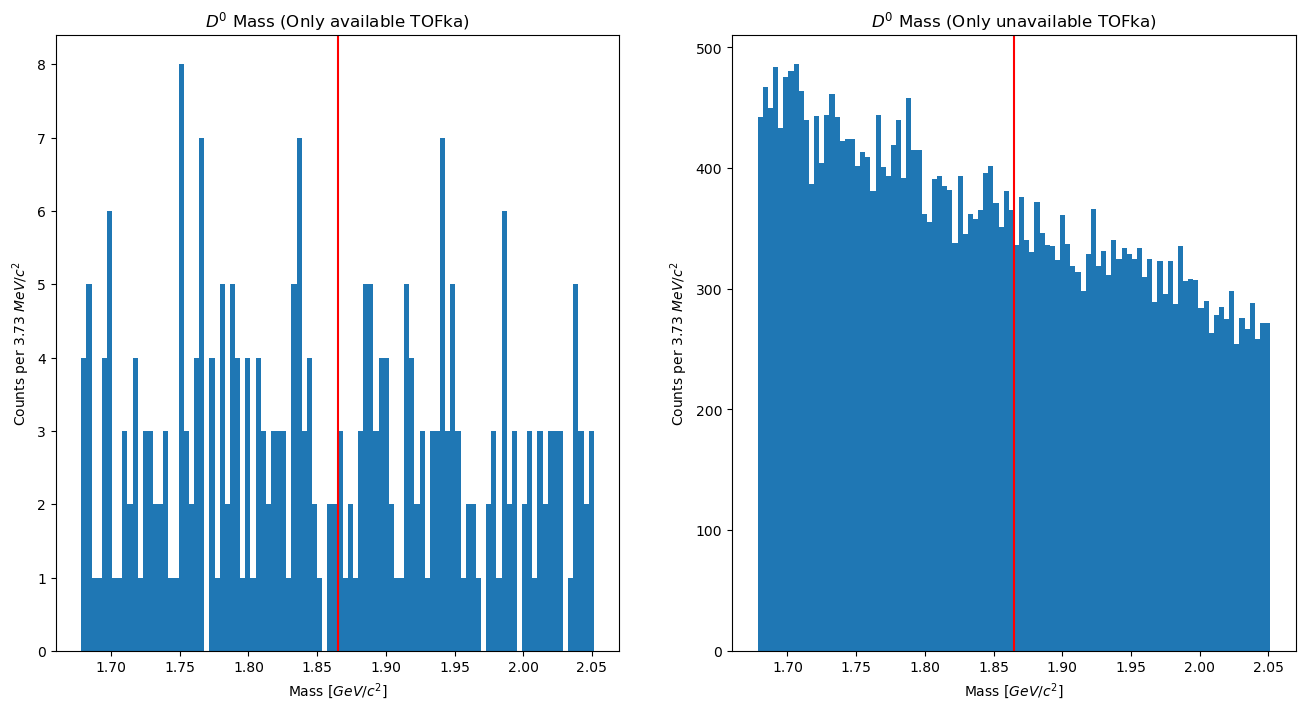

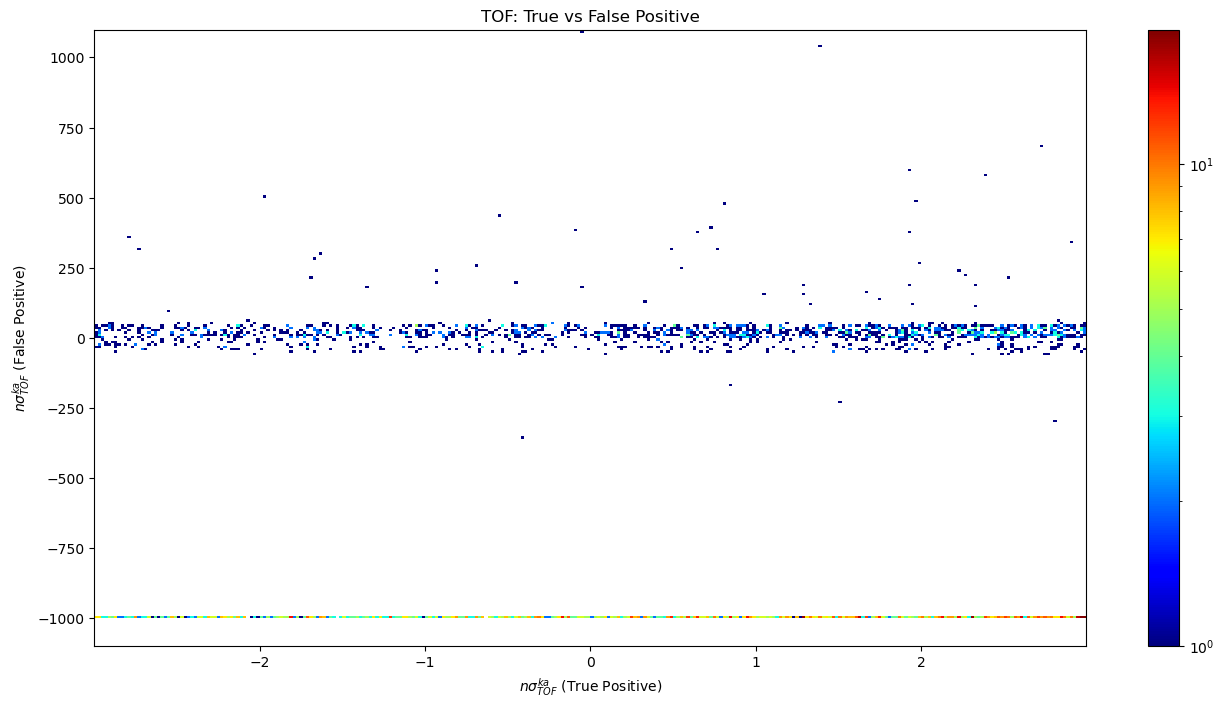

Fraction of True Positive Kaons with corresponding unavailable TOF in case of particle switch: 0.005495305659659582


In [11]:
# in cut2:
# "( (fNsigmaTOFka > -3) & (fNsigmaTOFka < 3) & (fCharge == -1) ) | "
# "( (fNsigmaTOFka > 998.5) | (fNsigmaTOFka < -998.5) |

min_cut_TOF_KA, max_cut_TOF_KA = -3, 3
NA_TOF_KA = 998.5
start_size = len(final_results)
middle_size = sum(final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA))
final_size = middle_size + sum(final_results["KA_TOFka"].abs() > NA_TOF_KA )
print("---KA only---")
print(f"True Positive data remaining for {min_cut_TOF_KA} < TOF_KA < {max_cut_TOF_KA}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True Positive data remaining for {min_cut_TOF_KA} < TOF_KA < {max_cut_TOF_KA} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")
print("\n---All particles---")
middle_size = sum( ( final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)  & (final_results["PI_TOFka"].abs() < NA_TOF_KA) ) |
                   ( final_results["PI_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)  & (final_results["KA_TOFka"].abs()< NA_TOF_KA) ) )
final_size = middle_size + sum( ( final_results["KA_TOFka"].abs() > NA_TOF_KA ) | ( final_results["PI_TOFka"].abs() > NA_TOF_KA ) )
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_KA < {max_cut_TOF_KA}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_KA < {max_cut_TOF_KA} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")

# Are rows corresponding to unavailable TOFka important? How does the invariant mass look without them?
only_available_TOF = final_results[( final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)  & (final_results["PI_TOFka"].abs() < NA_TOF_KA) ) |
                   ( final_results["PI_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)  & (final_results["KA_TOFka"].abs()< NA_TOF_KA) )]

MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
fig, ax  = plt.subplots(1, 2, figsize=(16,8))
ax[0].hist(only_available_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[0].axvline(x=m_d0, color="red")
ax[0].set_xlabel("Mass [$GeV/c^2$]")
ax[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[0].set_title("$D^0$ Mass (Only available TOFka)")

# only UNAVAILABLE
only_unavailable_TOF = final_results[( final_results["KA_TOFka"].abs() > NA_TOF_KA ) | ( final_results["PI_TOFka"].abs() > NA_TOF_KA ) ]
ax[1].hist(only_unavailable_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[1].axvline(x=m_d0, color="red")
ax[1].set_xlabel("Mass [$GeV/c^2$]")
ax[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[1].set_title("$D^0$ Mass (Only unavailable TOFka)")

plt.show()

# Check how the true positive and false positive are related
fig, ax = plt.subplots(figsize=(16,8))
plt.hist2d(final_results[( final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA))]["KA_TOFka"],
           final_results[( final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA))]["PI_TOFka"],
           (300, 300), cmap="jet", norm=LogNorm() )
plt.colorbar()
plt.xlabel(r"$n\sigma^{ka}_{TOF}$ (True Positive)")
plt.ylabel(r"$n\sigma^{ka}_{TOF}$ (False Positive)")
plt.ylim(-1.1*NA_TOF_KA, 1.1*NA_TOF_KA )
plt.title("TOF: True vs False Positive")
plt.show()

print("Fraction of True Positive Kaons with corresponding unavailable TOF in case of particle switch:",
      sum( (final_results["KA_TOFka"].between(min_cut_TOF_KA, max_cut_TOF_KA)) & ( (final_results["PI_TOFka"].abs() > NA_TOF_KA) ) )/len(final_results) )

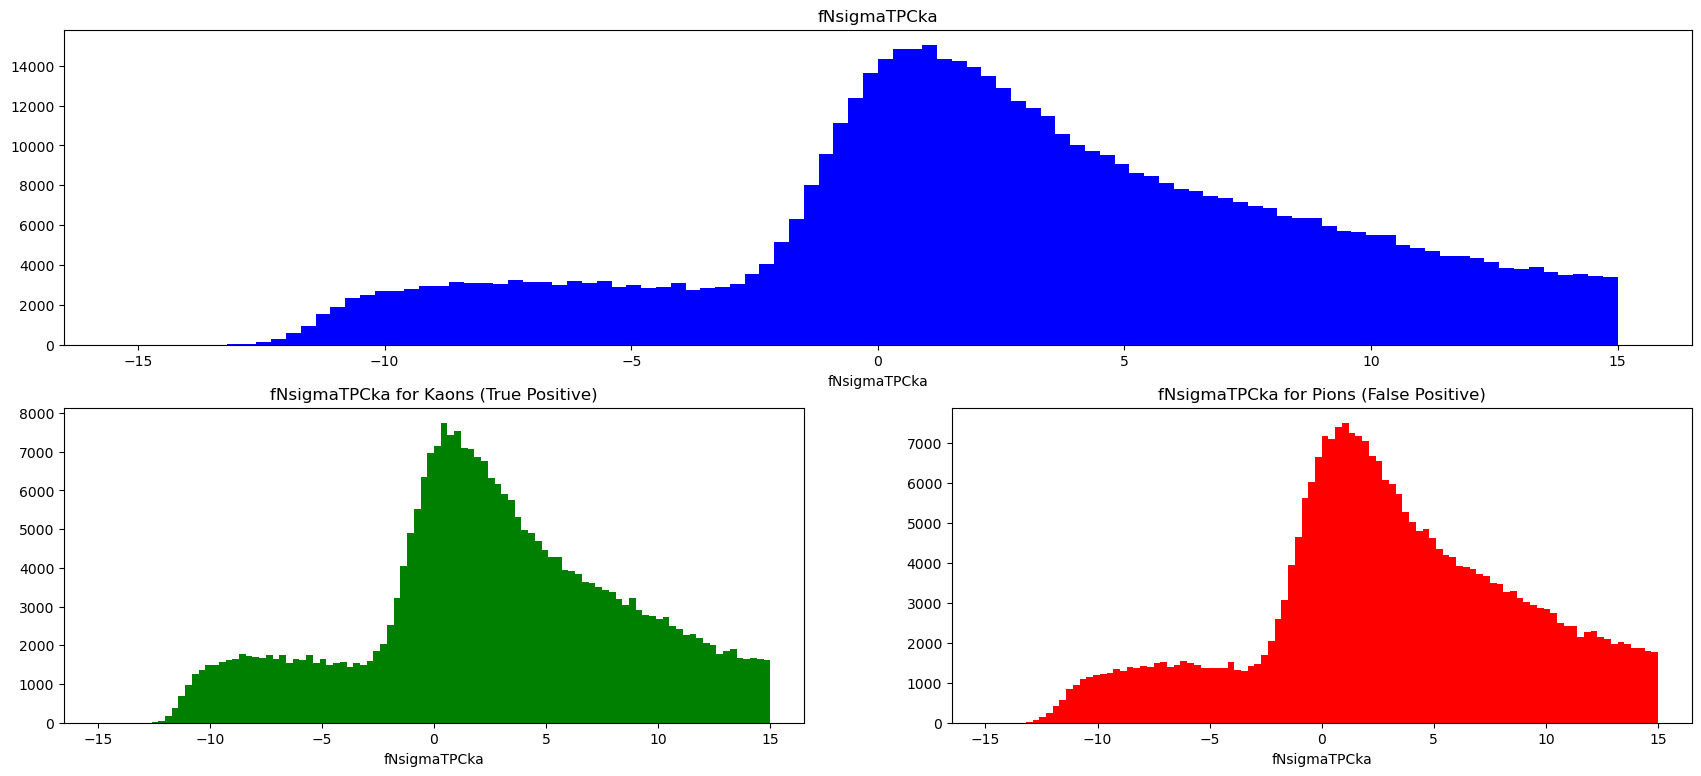

In [12]:
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TPC, MAX_TPC = -15, +15
axes["top"].hist(np.concat([final_results["KA_TPCka"],final_results["PI_TPCka"]]), bins=N_BINS, color="blue", range=(MIN_TPC, MAX_TPC))
axes["top"].set_title("fNsigmaTPCka")
axes["top"].set_xlabel("fNsigmaTPCka")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["KA_TPCka"], bins=N_BINS, color="green", range=(MIN_TPC, MAX_TPC))
axes["left"].set_title("fNsigmaTPCka for Kaons (True Positive)")
axes["left"].set_xlabel("fNsigmaTPCka")
axes["left"].set_label("Counts")

axes["right"].hist(final_results["PI_TPCka"], bins=N_BINS, color="red", range=(MIN_TPC, MAX_TPC))
axes["right"].set_title("fNsigmaTPCka for Pions (False Positive)")
axes["right"].set_xlabel("fNsigmaTPCka")
axes["right"].set_label("Counts")

plt.show()

---KA only---
True Positive data remaining for -3 < TPC_KA < 3:     32.44%   (227329 rows eliminated.)

---All particles---
True&False Positive data remaining for -3 < TPC_KA < 3:     52.92%   (158405 rows eliminated.)


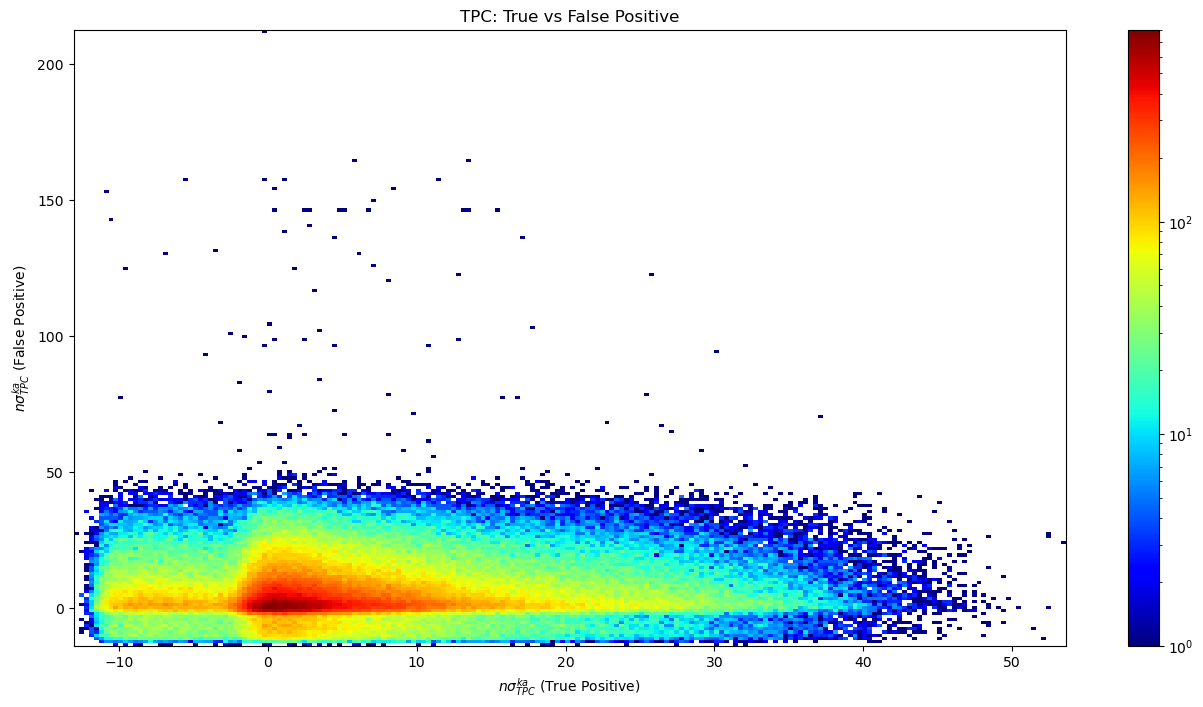

In [13]:
# in cut1:
# "( (fNsigmaTPCka > -3) & (fNsigmaTPCka < 3) & (fCharge == -1) ) | "
# "( (fPt > 0) & (fPt < 1) & (fNsigmaTPCka > -15) & (fNsigmaTPCka < 0) & (fCharge == 1) )"

min_cut_TPC_KA, max_cut_TPC_KA = -3, 3
start_size = len(final_results)
final_size = sum(final_results["KA_TPCka"].between(min_cut_TPC_KA, max_cut_TPC_KA))
print("---KA only---")
print(f"True Positive data remaining for {min_cut_TPC_KA} < TPC_KA < {max_cut_TPC_KA}:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")
print("\n---All particles---")
final_size = sum( ( final_results["KA_TPCka"].between(min_cut_TPC_KA, max_cut_TPC_KA) ) |
                   ( final_results["PI_TPCka"].between(min_cut_TPC_KA, max_cut_TPC_KA)  ) )
print(f"True&False Positive data remaining for {min_cut_TPC_KA} < TPC_KA < {max_cut_TPC_KA}:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")

# Check how the true positive and false positive are related
fig, ax = plt.subplots(figsize=(16,8))
plt.hist2d(final_results["KA_TPCka"], final_results["PI_TPCka"], (200, 200), cmap="jet", norm=LogNorm() )
plt.colorbar()
plt.xlabel(r"$n\sigma^{ka}_{TPC}$ (True Positive)")
plt.ylabel(r"$n\sigma^{ka}_{TPC}$ (False Positive)")
plt.title("TPC: True vs False Positive")
plt.show()

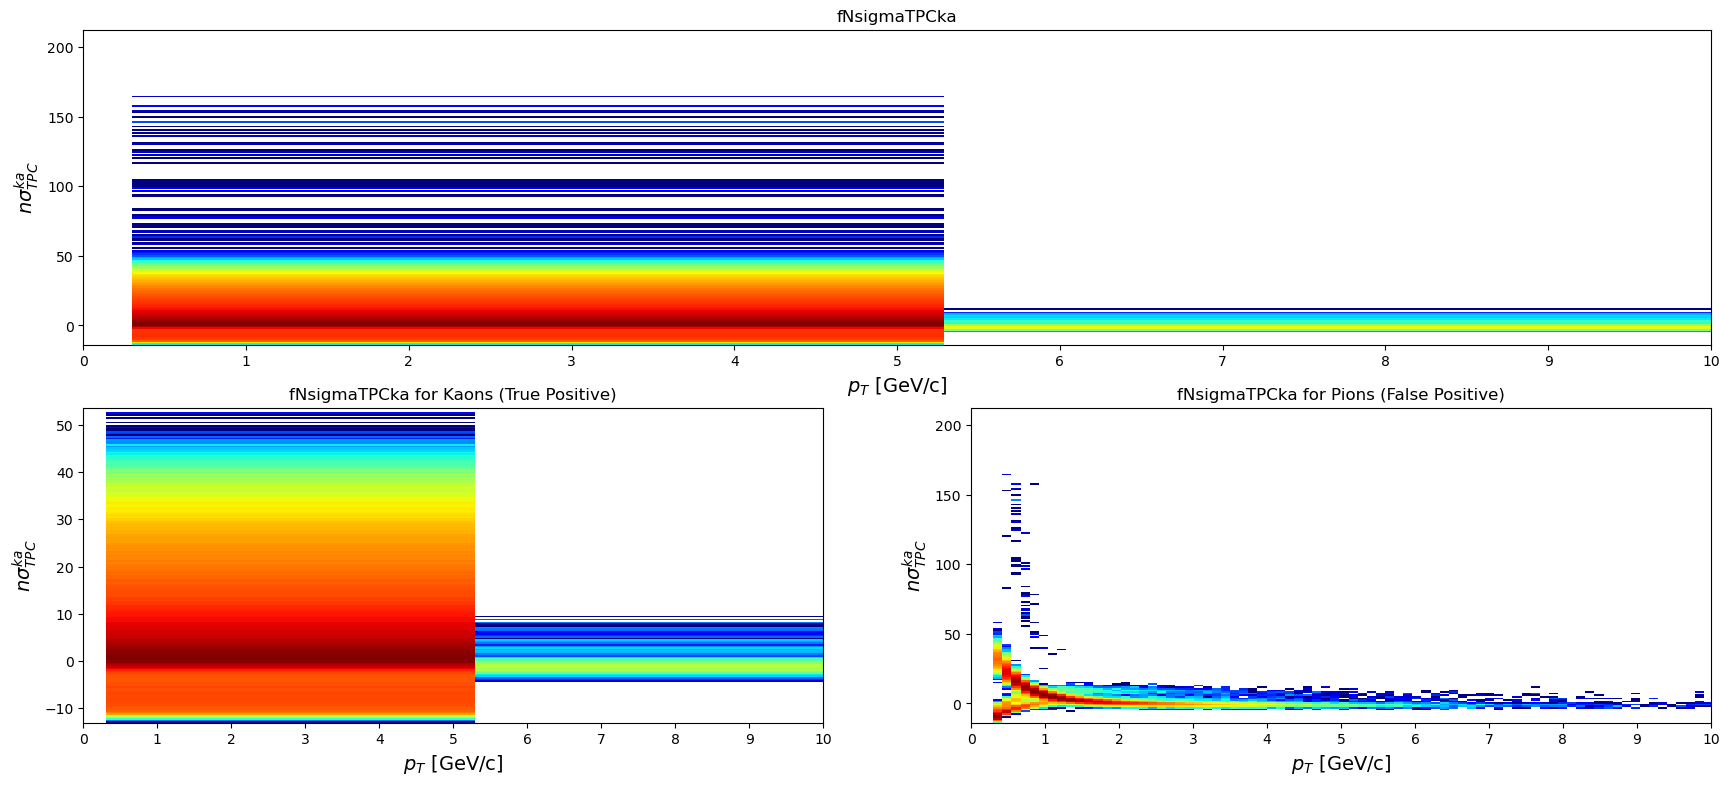

In [14]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["KA_TPCka"], final_results["PI_TPCka"]]), (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTPCka")


axes["left"].hist2d(final_results["KA_pt"], final_results["KA_TPCka"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTPCka for Kaons (True Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["PI_TPCka"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTPCka for Pions (False Positive)")

plt.show()

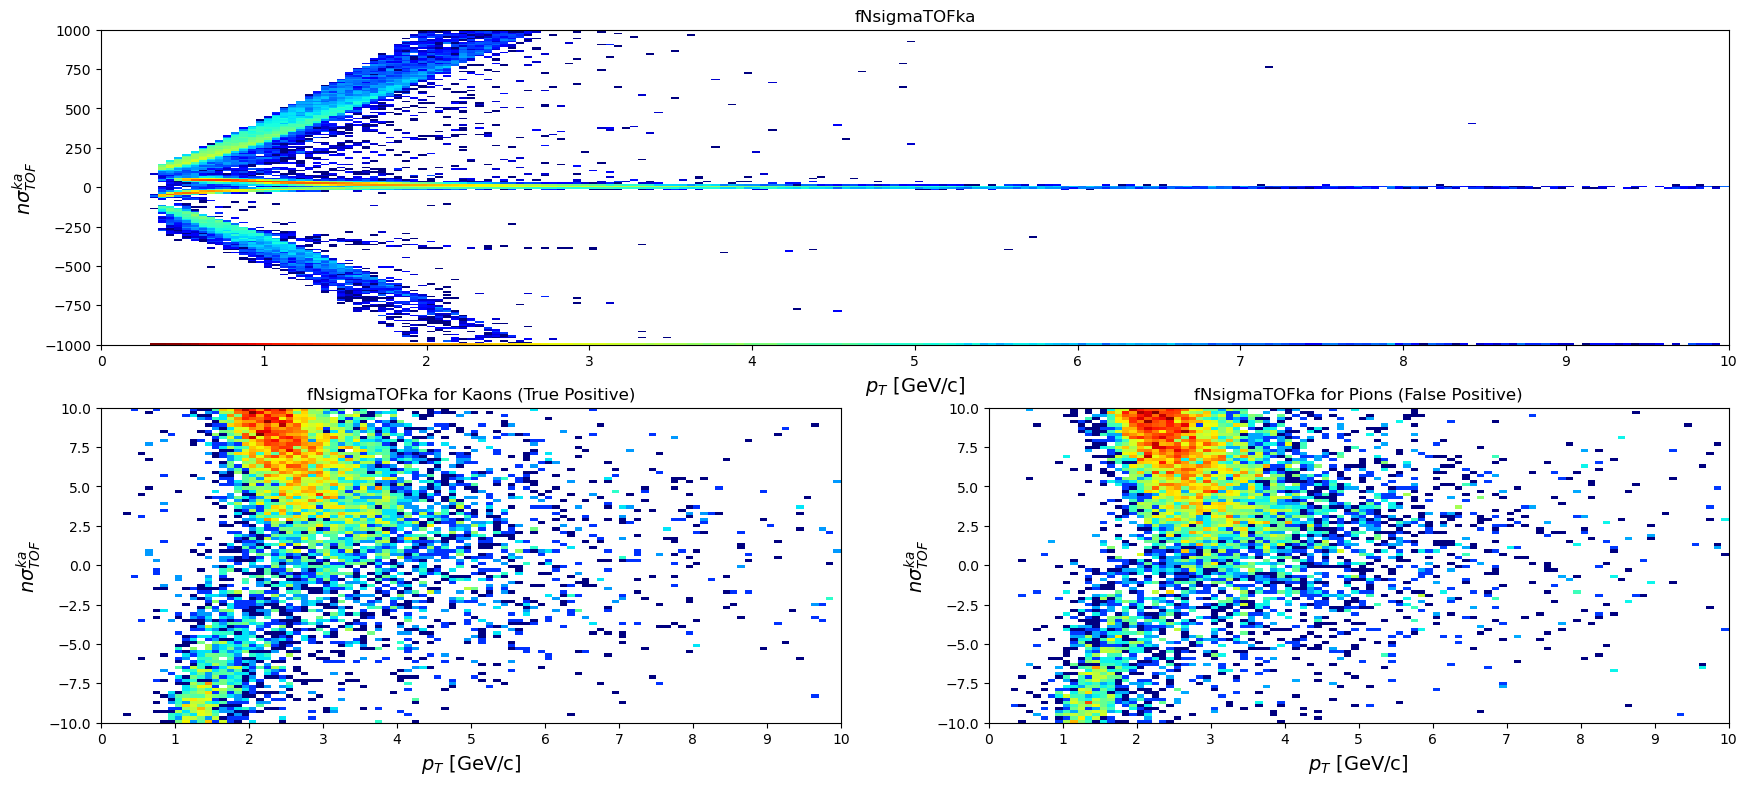

In [15]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
TOF_lower, TOF_upper = -1000, +1000
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["KA_TOFka"], final_results["PI_TOFka"]]), (200, 200), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[TOF_lower,TOF_upper]]))
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTOFka")


axes["left"].hist2d(final_results["KA_pt"], final_results["KA_TOFka"], (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTOFka for Kaons (True Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["PI_TOFka"], (100, 100), cmap="jet", norm=LogNorm(),
                     range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTOFka for Pions (False Positive)")

plt.show()

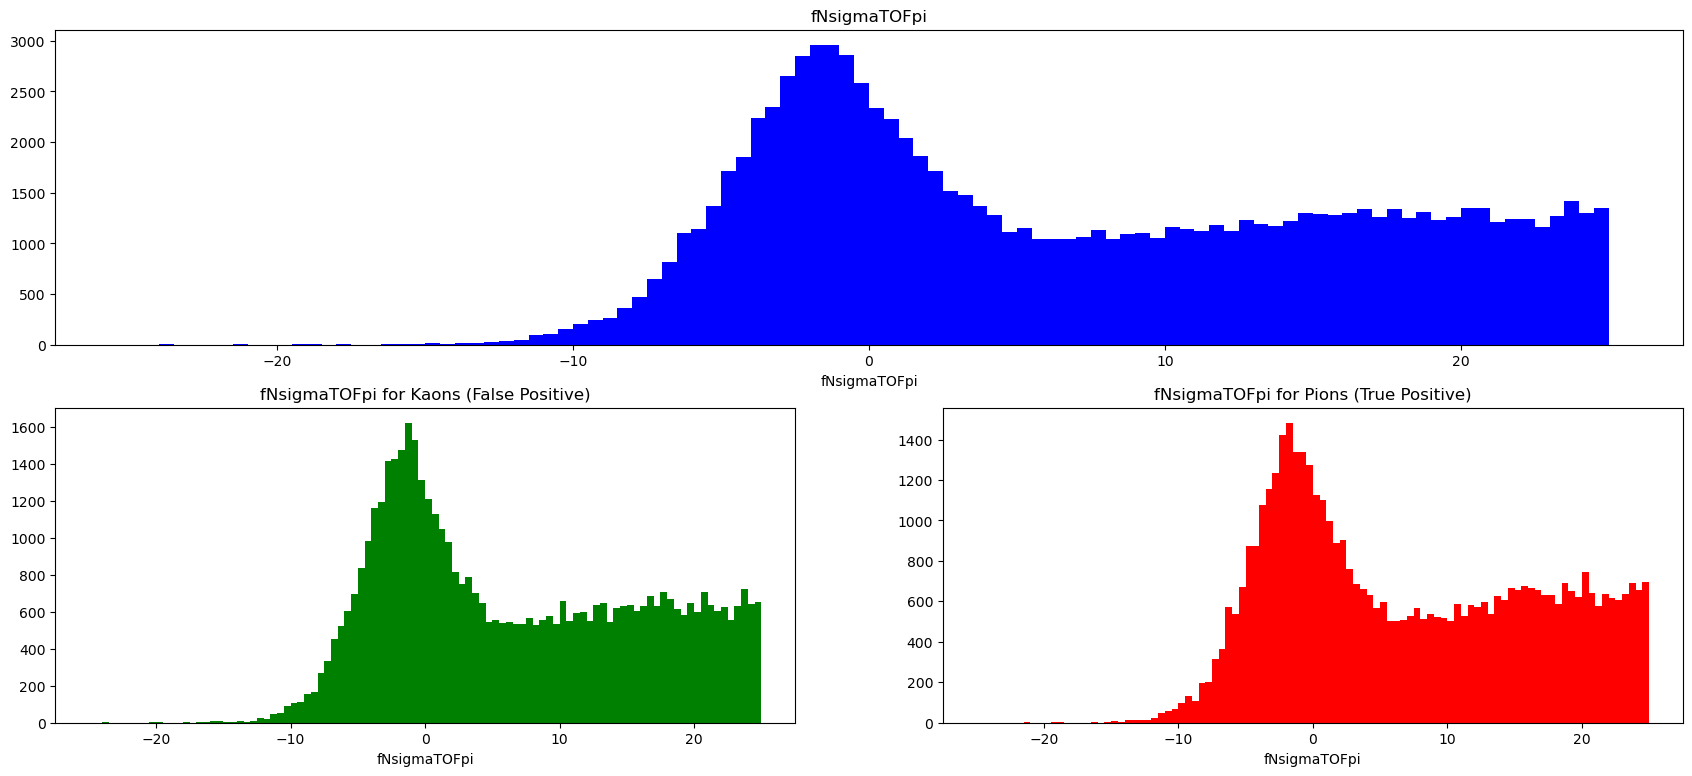

In [16]:
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TOF, MAX_TOF = -25, 25
axes["top"].hist(np.concat([final_results["KA_TOFpi"],final_results["PI_TOFpi"]]), bins=N_BINS, color="blue", range=(MIN_TOF, MAX_TOF))
axes["top"].set_title("fNsigmaTOFpi")
axes["top"].set_xlabel("fNsigmaTOFpi")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["KA_TOFpi"], bins=N_BINS, color="green", range=(MIN_TOF, MAX_TOF))
axes["left"].set_title("fNsigmaTOFpi for Kaons (False Positive)")
axes["left"].set_xlabel("fNsigmaTOFpi")
axes["left"].set_label("Counts")

axes["right"].hist(final_results["PI_TOFpi"], bins=N_BINS, color="red", range=(MIN_TOF, MAX_TOF))
axes["right"].set_title("fNsigmaTOFpi for Pions (True Positive)")
axes["right"].set_xlabel("fNsigmaTOFpi")
axes["right"].set_label("Counts")

plt.show()

---Pion only---
True Positive data remaining for -3 < TOF_PI < 3:     4.12%   (322610 rows eliminated.)
True Positive data remaining for -3 < TOF_PI < 3 or unavailable:     67.22%   (110288 rows eliminated.)

---All particles---
True&False Positive data remaining for -3 < TOF_PI < 3:     3.26%   (325494 rows eliminated.)
True&False Positive data remaining for -3 < TOF_PI < 3 or unavailable:     88.32%   (39304 rows eliminated.)


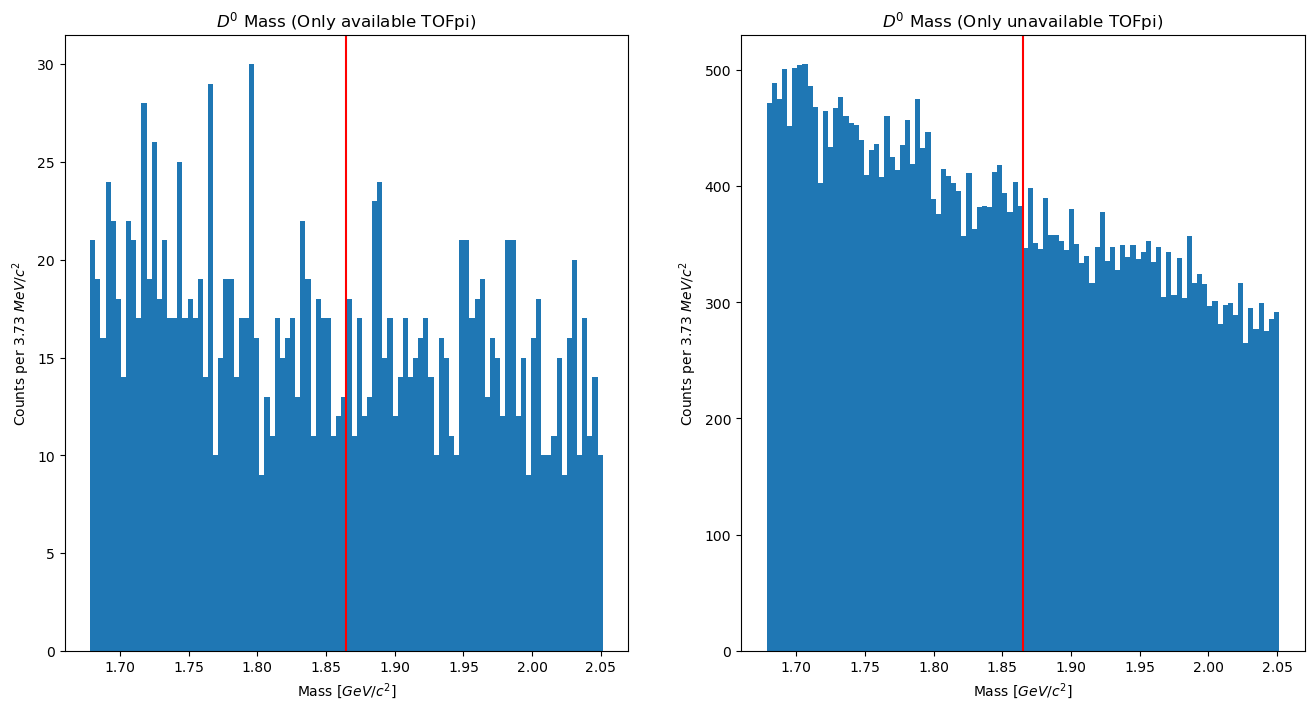

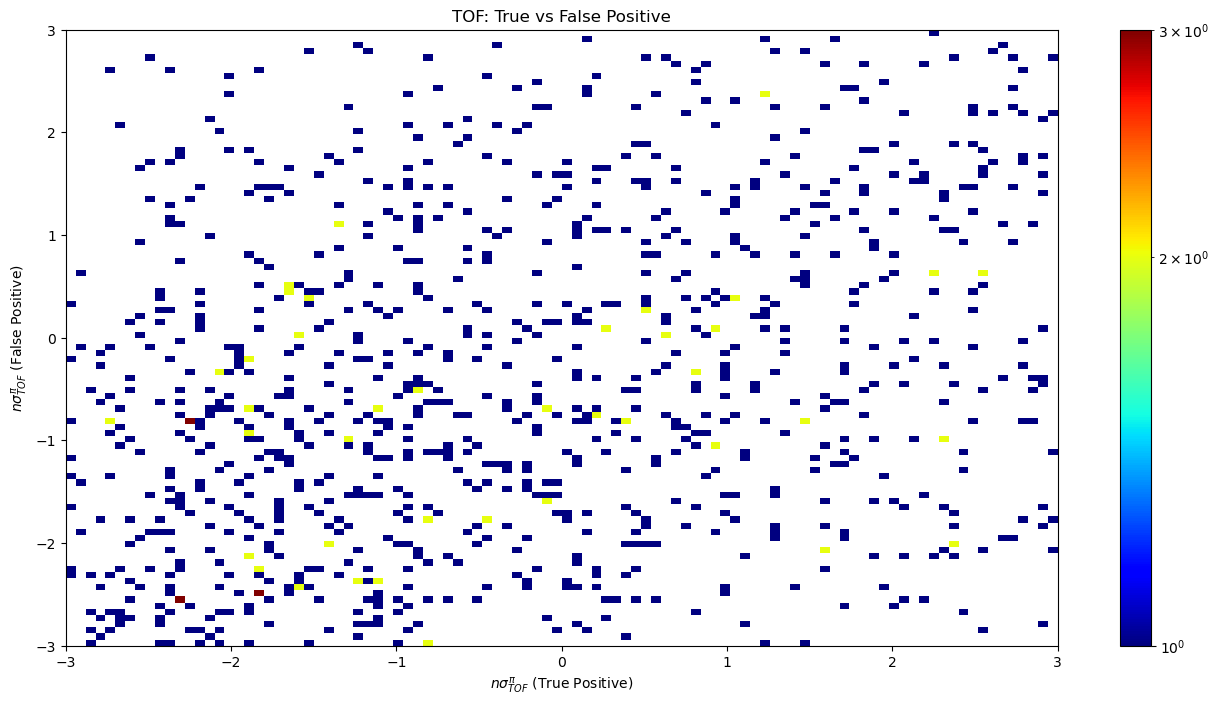

Fraction of True Positive Pions with corresponding unavailable TOF in case of particle switch: 0.02429049927333573


In [17]:
# in cut2:
# "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
# "(fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "

min_cut_TOF_PI, max_cut_TOF_PI = -3, 3
NA_TOF_PI = 998.5
start_size = len(final_results)
middle_size = sum(final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI))
final_size = middle_size + sum(final_results["PI_TOFpi"].abs() > NA_TOF_PI )
print("---Pion only---")
print(f"True Positive data remaining for {min_cut_TOF_PI} < TOF_PI < {max_cut_TOF_PI}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True Positive data remaining for {min_cut_TOF_PI} < TOF_PI < {max_cut_TOF_PI} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")
print("\n---All particles---")
middle_size = sum( ( final_results["KA_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["PI_TOFpi"].abs() < NA_TOF_PI) ) |
                   ( final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["KA_TOFpi"].abs()< NA_TOF_PI) ) )
final_size = middle_size + sum( ( final_results["KA_TOFpi"].abs() > NA_TOF_PI ) | ( final_results["PI_TOFpi"].abs() > NA_TOF_PI ) )
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_PI < {max_cut_TOF_KA}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_PI < {max_cut_TOF_KA} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")

# Are rows corresponding to unavailable TOFpi important? How does the invariant mass look without them?
only_available_TOF = final_results[( final_results["KA_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["PI_TOFpi"].abs() < NA_TOF_PI) ) |
                   ( final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["KA_TOFpi"].abs()< NA_TOF_PI) )]

MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
fig, ax  = plt.subplots(1, 2, figsize=(16,8))
ax[0].hist(only_available_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[0].axvline(x=m_d0, color="red")
ax[0].set_xlabel("Mass [$GeV/c^2$]")
ax[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[0].set_title("$D^0$ Mass (Only available TOFpi)")

# only UNAVAILABLE
only_unavailable_TOF = final_results[( final_results["KA_TOFpi"].abs() > NA_TOF_PI ) | ( final_results["PI_TOFpi"].abs() > NA_TOF_PI ) ]
ax[1].hist(only_unavailable_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[1].axvline(x=m_d0, color="red")
ax[1].set_xlabel("Mass [$GeV/c^2$]")
ax[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[1].set_title("$D^0$ Mass (Only unavailable TOFpi)")

plt.show()

test = final_results[final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)]
test = test[test["KA_TOFpi"].between(-10,10)]

# Check how the true positive and false positive are related
fig, ax = plt.subplots(figsize=(16,8))
# plt.hist2d(final_results[( final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI))]["PI_TOFpi"],
#            final_results[( final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI))]["KA_TOFpi"],
#            (400, 400), cmap="jet", norm=LogNorm() )
plt.hist2d(test["PI_TOFpi"],
           test["KA_TOFpi"],
           (100, 100), cmap="jet", norm=LogNorm(), range=[[-3, 3], [-3, 3]] )

plt.colorbar()
plt.xlabel(r"$n\sigma^{\pi}_{TOF}$ (True Positive)")
plt.ylabel(r"$n\sigma^{\pi}_{TOF}$ (False Positive)")
#plt.ylim(-1.1*NA_TOF_PI, 1.1*NA_TOF_PI )
plt.title("TOF: True vs False Positive")
plt.show()

print("Fraction of True Positive Pions with corresponding unavailable TOF in case of particle switch:",
      sum( (final_results["PI_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)) & ( (final_results["KA_TOFpi"].abs() > NA_TOF_PI) ) )/len(final_results) )

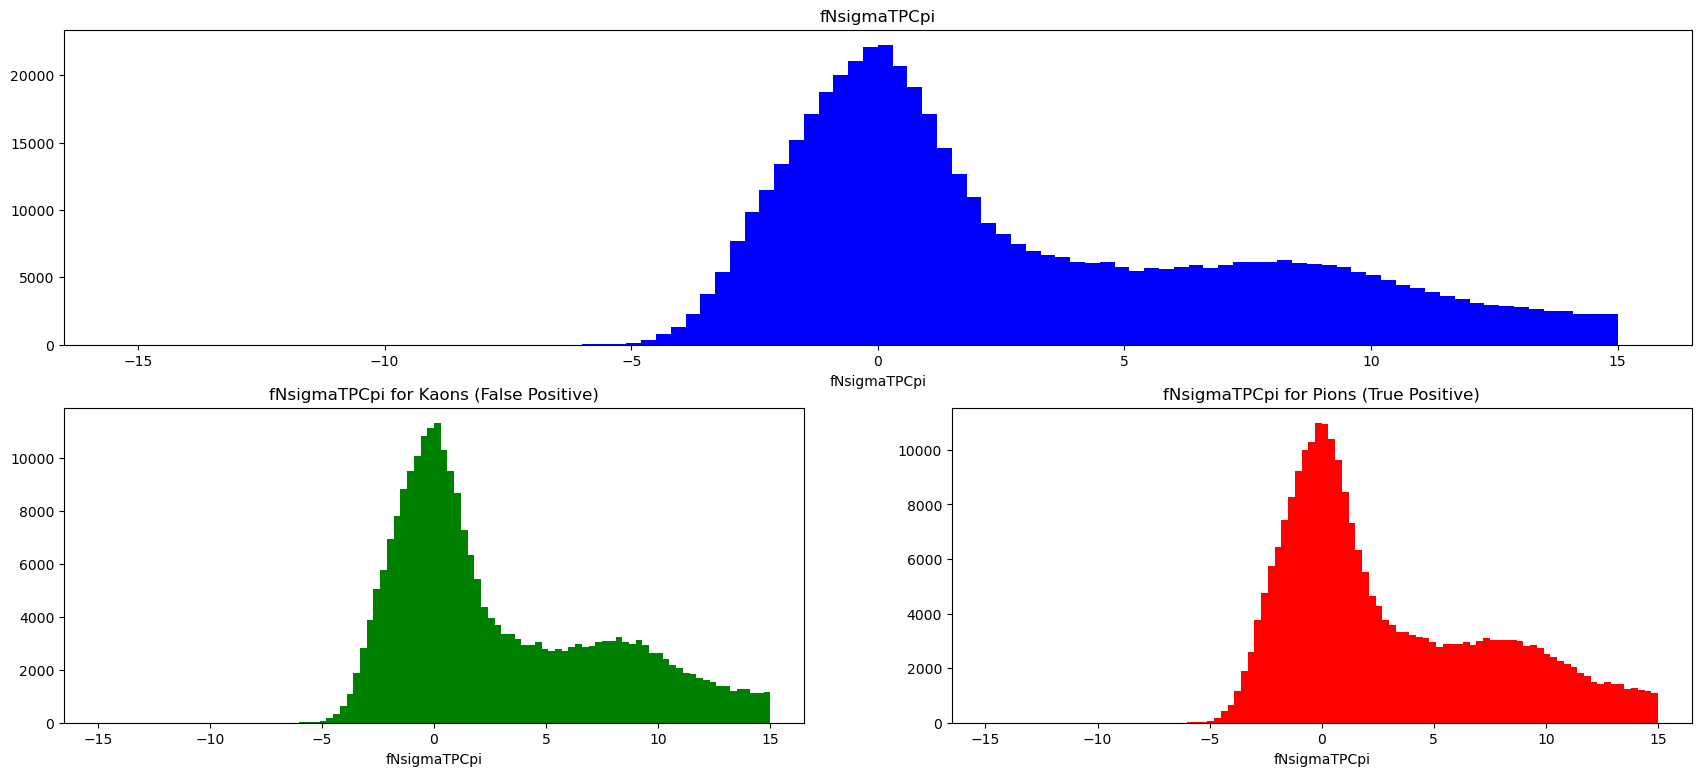

In [18]:
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TPC, MAX_TPC = -15, +15
axes["top"].hist(np.concat([final_results["KA_TPCpi"],final_results["PI_TPCpi"]]), bins=N_BINS, color="blue", range=(MIN_TPC, MAX_TPC))
axes["top"].set_title("fNsigmaTPCpi")
axes["top"].set_xlabel("fNsigmaTPCpi")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["KA_TPCpi"], bins=N_BINS, color="green", range=(MIN_TPC, MAX_TPC))
axes["left"].set_title("fNsigmaTPCpi for Kaons (False Positive)")
axes["left"].set_xlabel("fNsigmaTPCpi")
axes["left"].set_label("Counts")

axes["right"].hist(final_results["PI_TPCpi"], bins=N_BINS, color="red", range=(MIN_TPC, MAX_TPC))
axes["right"].set_title("fNsigmaTPCpi for Pions (True Positive)")
axes["right"].set_xlabel("fNsigmaTPCpi")
axes["right"].set_label("Counts")

plt.show()

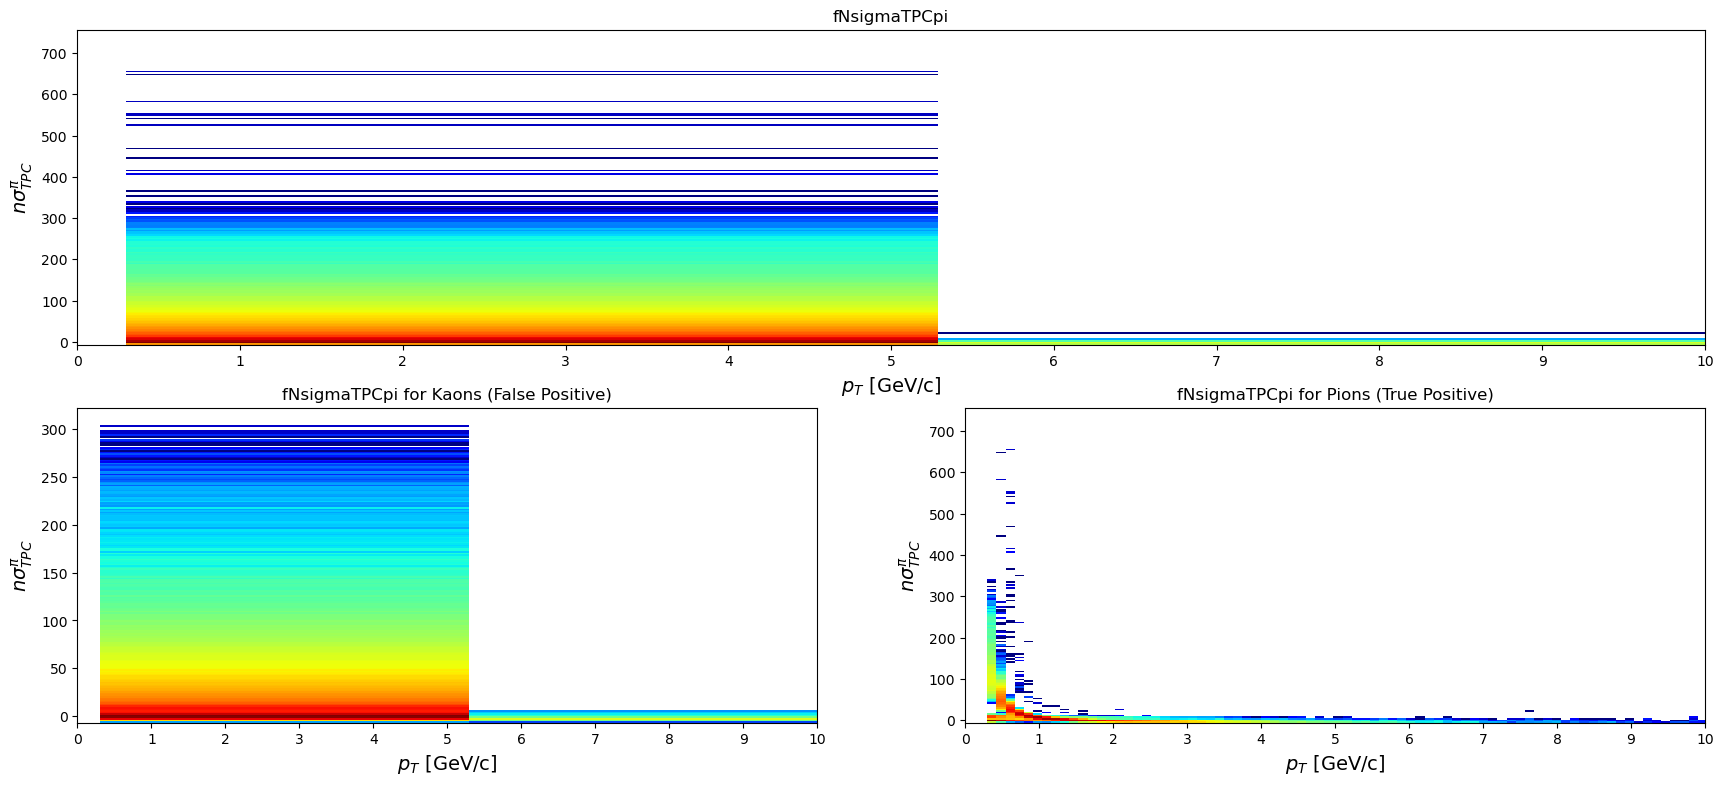

In [19]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["KA_TPCpi"], final_results["PI_TPCpi"]]), (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTPCpi")


axes["left"].hist2d(final_results["KA_pt"], final_results["KA_TPCpi"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTPCpi for Kaons (False Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["PI_TPCpi"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTPCpi for Pions (True Positive)")

plt.show()

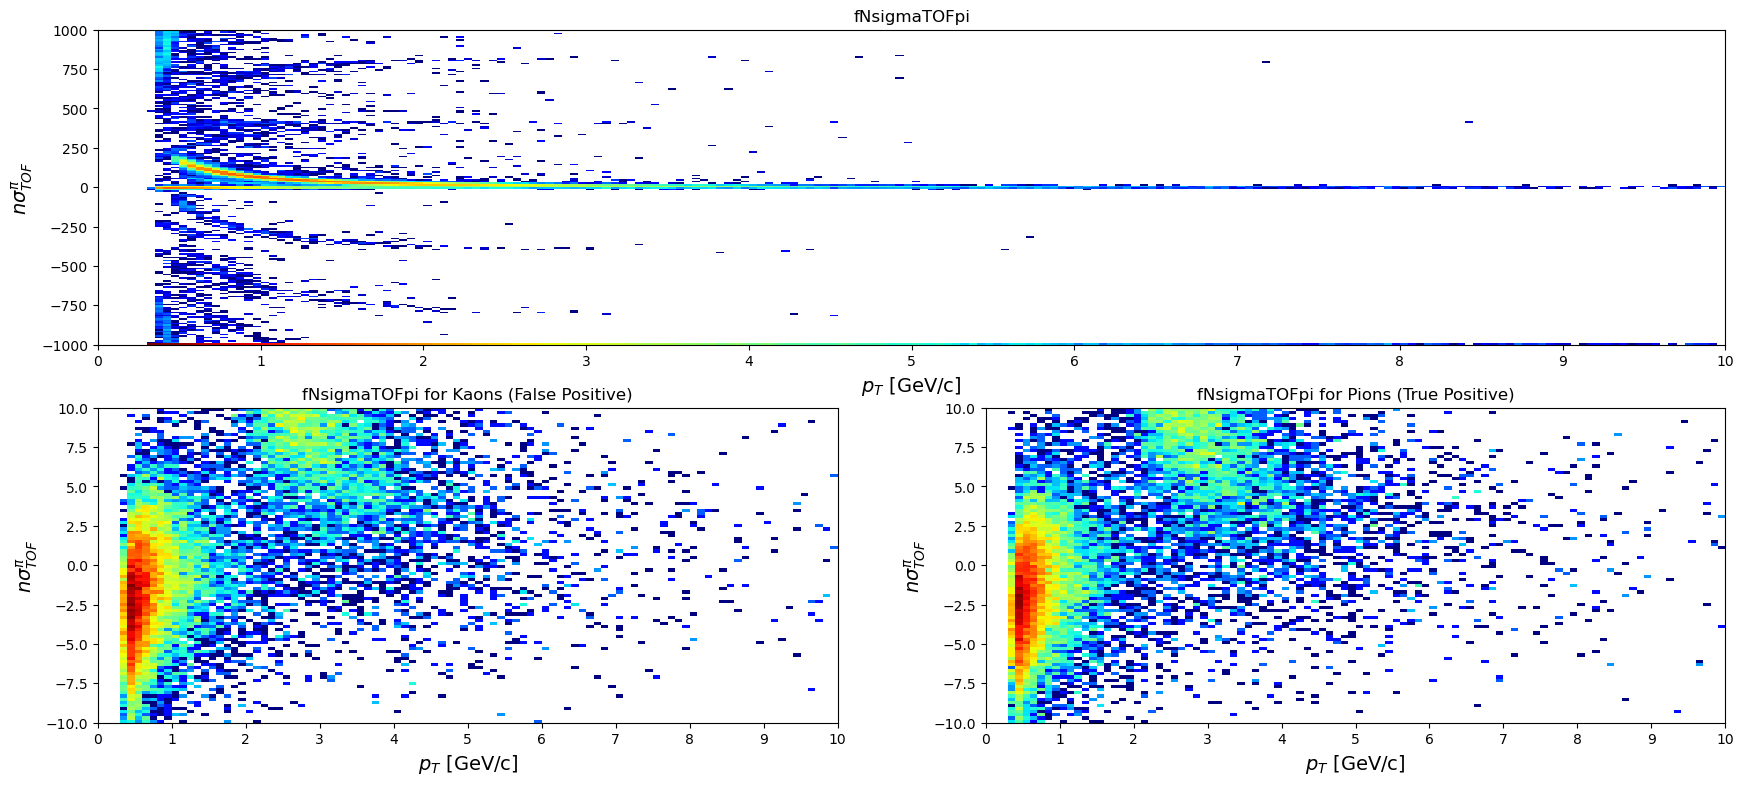

In [20]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
TOF_lower, TOF_upper = -1000, +1000
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["KA_TOFpi"], final_results["PI_TOFpi"]]), (200, 200), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[TOF_lower,TOF_upper]]))
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTOFpi")


axes["left"].hist2d(final_results["KA_pt"], final_results["KA_TOFpi"], (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTOFpi for Kaons (False Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["PI_TOFpi"], (100, 100), cmap="jet", norm=LogNorm(),
                     range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTOFpi for Pions (True Positive)")

plt.show()

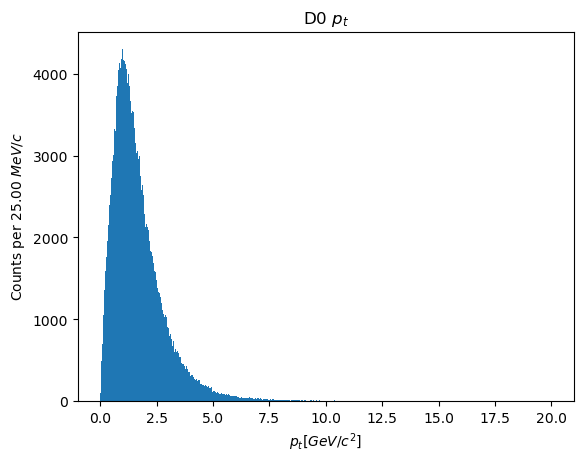

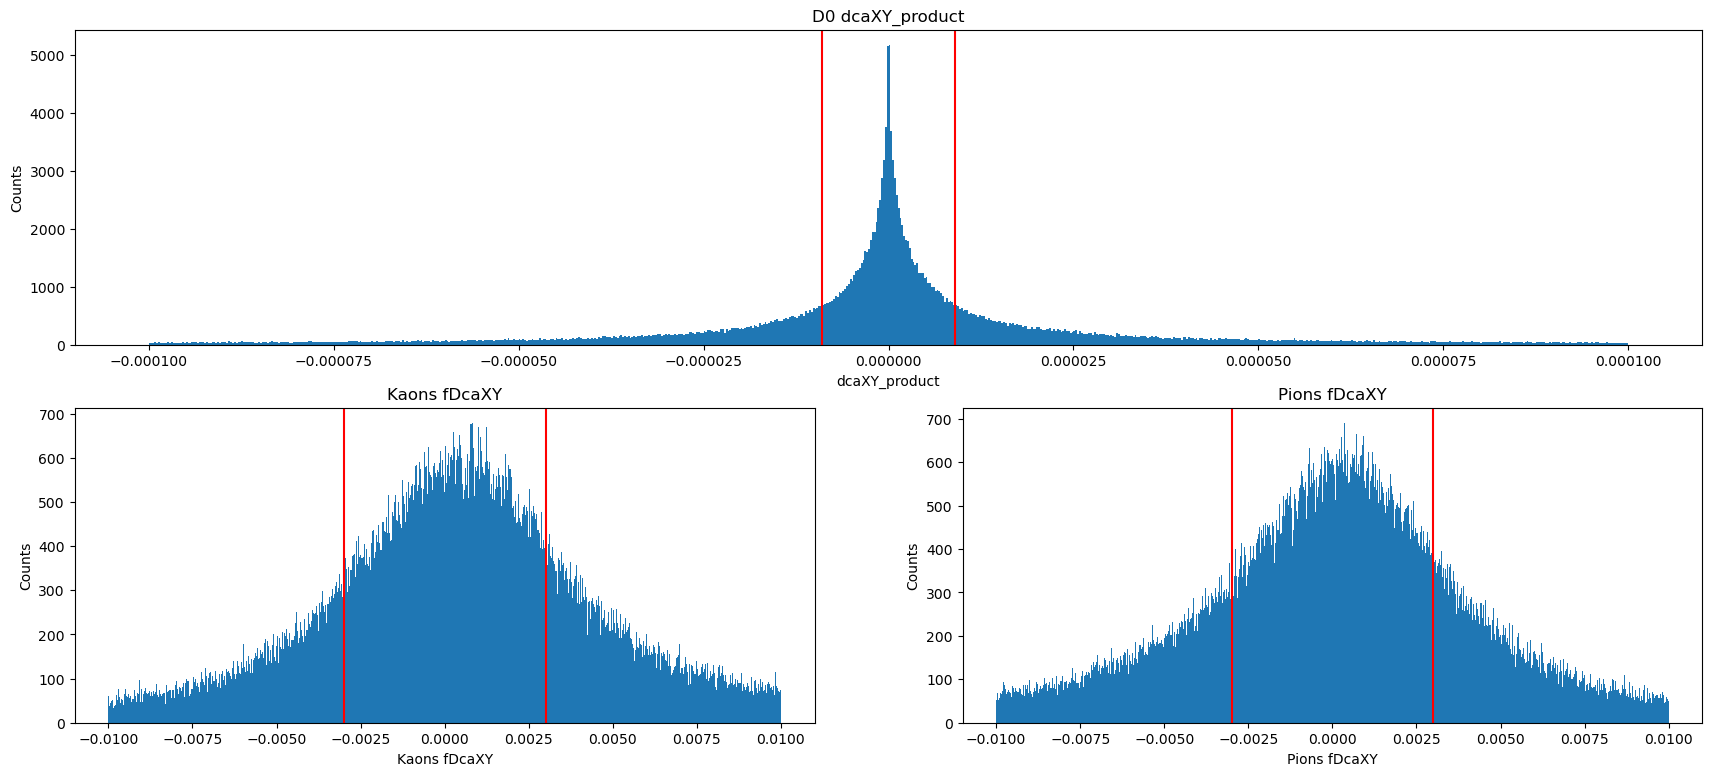

In [21]:
MIN_pt, MAX_pt = 0, 20
N_BINS = 800
plt.hist(final_results["pt"], range=(MIN_pt, MAX_pt), bins=N_BINS)
plt.xlabel("$p_t [GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_pt -  MIN_pt)/N_BINS)*1000:.2f} $MeV/c$")
plt.title("D0 $p_t$")
plt.show()

# MIN_DCAXY, MAX_DCAXY = np.quantile(final_results["dcaXY_product"], 0.01), np.quantile(final_results["dcaXY_product"], 0.99)
MIN_DCAXY, MAX_DCAXY = -1e-04, +1e-04
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist(final_results["dcaXY_product"], bins=N_BINS, range=(MIN_DCAXY, MAX_DCAXY))
axes["top"].set_xlabel("dcaXY_product")
axes["top"].set_ylabel(f"Counts")
axes["top"].set_title("D0 dcaXY_product")
axes["top"].axvline(x=-3e-03**2, color="red")
axes["top"].axvline(x=+3e-03**2, color="red")

axes["left"].hist(final_results["KA_fDcaXY"], bins=N_BINS, range=(-np.sqrt(-MIN_DCAXY),np.sqrt(MAX_DCAXY)))
axes["left"].set_xlabel("Kaons fDcaXY")
axes["left"].set_ylabel(f"Counts")
axes["left"].set_title("Kaons fDcaXY")
axes["left"].axvline(x=-3e-03, color="red")
axes["left"].axvline(x=+3e-03, color="red")

axes["right"].hist(final_results["PI_fDcaXY"], bins=N_BINS, range=(-np.sqrt(-MIN_DCAXY),np.sqrt(MAX_DCAXY)))
axes["right"].set_xlabel("Pions fDcaXY")
axes["right"].set_ylabel(f"Counts")
axes["right"].set_title("Pions fDcaXY")
axes["right"].axvline(x=-3e-03, color="red")
axes["right"].axvline(x=+3e-03, color="red")
plt.show()

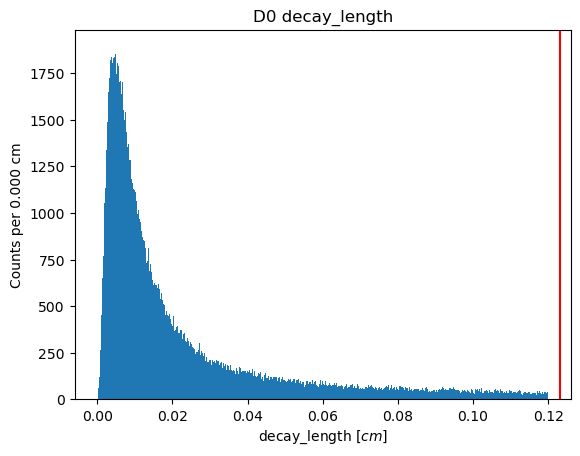

In [22]:
MIN_dl, MAX_dl = 0, 0.12
N_BINS = 800
plt.hist(final_results["decay_length"], bins=N_BINS, range=(MIN_dl, MAX_dl))
plt.xlabel("decay_length $[cm]$")
plt.ylabel(f"Counts per {((MAX_dl - MIN_dl)/N_BINS):.3f} cm")
plt.axvline(x=1.23*10e-02, color="red")
plt.title("D0 decay_length")
plt.show()

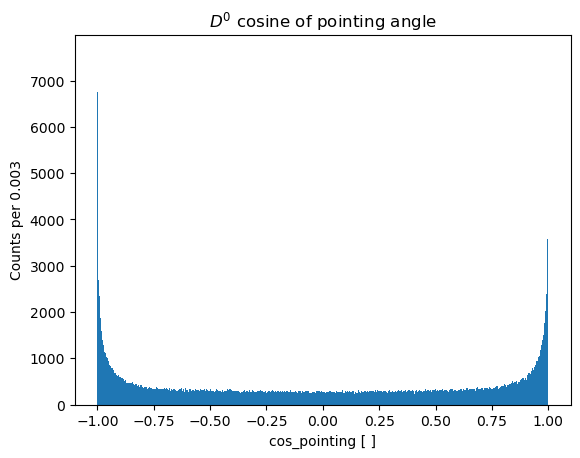

In [23]:
MIN_cos, MAX_cos = -1, 1
N_BINS = 800
plt.hist(final_results["cos_pointing"], bins=N_BINS, range=(MIN_cos, MAX_cos))
plt.xlabel("cos_pointing [ ]")
plt.ylabel(f"Counts per {((MAX_cos - MIN_cos)/N_BINS):.3f}")
plt.title("$D^0$ cosine of pointing angle")
plt.show()

In [24]:
# converting the cuts to work for this
# cut1 = (
#     "( (fNsigmaTPCpi > -3) & (fNsigmaTPCpi < 3) & (fCharge == 1) ) | "
#     "( (fNsigmaTPCka > -3) & (fNsigmaTPCka < 3) & (fCharge == -1) ) | "
#     "( (fPt > 0) & (fPt < 1) & (fNsigmaTPCka > -15) & (fNsigmaTPCka < 0) & (fCharge == 1) )"
# )

# # NsigmaTOF:
# sigma_limit = 3
# cut2 = (
#     "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
#     "( (fNsigmaTOFka > -3) & (fNsigmaTOFka < 3) & (fCharge == -1) ) | "
#     "( (fNsigmaTOFka > 998.5) | (fNsigmaTOFka < -998.5) | (fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "
#     "( (fPt > 0) & (fPt < 3) & (fNsigmaTOFka > -50) & (fNsigmaTOFka < 0) & (fCharge == 1) )"
# )

# # DCA_XY:
# cut3 = "( (fDcaXY > 0.0002) | (fDcaXY < -0.0002) )"


# # FINAL CUT EXPRESSION:
# cut_expression = f"({cut1}) & ({cut2}) & ({cut3})"

TOF_cut = 5
TPC_cut = 3
DCA_cut = 3e-03

cut1_A = final_results["PI_TPCpi"].between(-TPC_cut, +TPC_cut)
cut1_B = final_results["KA_TPCka"].between(-TPC_cut, +TPC_cut)
cut1_C = ( final_results["PI_pt"].between(0,1) ) & (final_results["KA_TPCka"].between(-15,0) )

cut1 = cut1_A | cut1_B | cut1_C

cut2_A = final_results["PI_TOFpi"].between(-TOF_cut, +TOF_cut)
cut2_B = final_results["KA_TOFka"].between(-TOF_cut, +TOF_cut)
cut2_C = ( np.isclose(final_results["PI_TOFpi"], -999.0) ) | ( np.isclose(final_results["KA_TOFka"], -999.0) )
cut2_D = ( final_results["PI_pt"].between(0,3) ) & (final_results["KA_TOFka"].between(-50,0) )

cut2 = cut2_A | cut2_B | cut2_C | cut2_D

cut3 = ( final_results["KA_fDcaXY"].abs() >= DCA_cut ) & ( final_results["PI_fDcaXY"].abs() >= DCA_cut )

final_cut = cut1 & cut2 & cut3

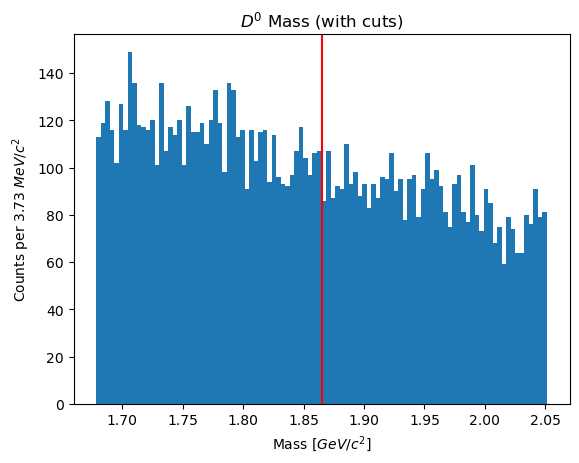

Amount of remaining data after cuts: 25.07%


,1A,1B,1C,2A,2B,2C,2D,TOT_1,TOT_2,TOT_3,FINAL
0,0.44024,0.324369,0.140049,0.060609,0.019018,0.814931,0.065409,0.673557,0.870553,0.445988,0.250707


In [25]:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
plt.hist(final_results[final_cut]["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
plt.axvline(x=m_d0, color="red")
plt.xlabel("Mass [$GeV/c^2$]")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
plt.title("$D^0$ Mass (with cuts)")
#plt.savefig("D0_Mass_MC.png")
plt.show()
print(f"Amount of remaining data after cuts: {sum(final_cut)/len(final_results)*100:.2f}%")

cut_effect = pd.DataFrame({
    "1A": sum(cut1_A)/len(final_results),
    "1B": sum(cut1_B)/len(final_results),
    "1C": sum(cut1_C)/len(final_results),
    "2A": sum(cut2_A)/len(final_results),
    "2B": sum(cut2_B)/len(final_results),
    "2C": sum(cut2_C)/len(final_results),
    "2D": sum(cut2_D)/len(final_results),
    "TOT_1": sum(cut1)/len(final_results),
    "TOT_2": sum(cut2)/len(final_results),
    "TOT_3":  sum(cut3)/len(final_results),
    "FINAL": sum(final_cut)/len(final_results)
}, index=[0])
display(cut_effect)